# Phân tích cảm xúc văn bản tài chính và ứng dụng trên báo cáo thường niên của doanh nghiệp

**Financial Text Sentiment Analysis and Its Application to Corporate Annual Reports**

Notebook này là **file code chính duy nhất** của bài cuối học phần NLP. Có thể chạy trên Google Colab hoặc Visual Studio Code bằng cách chọn **Restart Kernel and Run All**.

## Phân công công việc

| Thành viên | MSSV | Tỷ trọng | Phần công việc chính |
|---|---|---:|---|
| Nguyễn Tùng Dương | [MSSV] | 33% | Thu thập dữ liệu, kiểm tra dữ liệu, tiền xử lý, EDA, chia dữ liệu, xây dựng phần phương pháp, viết và tích hợp báo cáo |
| Phạm Thế Duy | [MSSV] | 33% | Xây dựng baseline và FinBERT, huấn luyện, đánh giá mô hình, confusion matrix, so sánh kết quả và phân tích lỗi |
| [Ngô Quang Thiện] | [MSSV] | 33% | Ứng dụng mô hình lên báo cáo PDF, tổng hợp và trực quan hóa kết quả, xây dựng slide, chuẩn bị bảo vệ và kiểm tra bản trình bày |


## 1. Mục tiêu và quy trình

Bài toán là phân loại cảm xúc của câu tài chính tiếng Anh thành ba lớp: **negative**, **neutral** và **positive**. Dữ liệu huấn luyện chính là Financial PhraseBank cấu hình `sentences_75agree`. Sau khi huấn luyện và đánh giá mô hình, mô hình tốt nhất được dùng để minh họa phân tích các câu trích xuất từ một báo cáo thường niên PDF.

Quy trình: tải dữ liệu → tiền xử lý → EDA → chia train/validation/test → huấn luyện baseline → FinBERT → đánh giá → phân tích lỗi → ứng dụng PDF.

## 2. Cài đặt và import thư viện

Cell này cài đặt thư viện khi chạy trên Google Colab. Khi chạy bằng Visual Studio Code, nên cài trước bằng `pip install -r requirements.txt`.

In [4]:
import sys, subprocess, importlib.util, platform
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip install -q pandas numpy matplotlib scikit-learn datasets pyarrow huggingface_hub transformers accelerate evaluate torch joblib pymupdf pdfplumber

import os, re, time, random, unicodedata, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
print('Python:', platform.python_version())
print('pandas:', pd.__version__)
try:
    import sklearn, transformers, torch
    print('scikit-learn:', sklearn.__version__)
    print('transformers:', transformers.__version__)
    print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
except Exception as e:
    print('Một số thư viện nâng cao chưa sẵn sàng:', e)

Python: 3.13.5
pandas: 2.3.3
Một số thư viện nâng cao chưa sẵn sàng: No module named 'transformers'


## 3. Cấu hình chung

Chỉ cần sửa các biến trong cell này. Nếu máy không có GPU, nên đặt `RUN_FINBERT = False` hoặc chạy trên Google Colab GPU.

In [14]:
import random
from pathlib import Path

import numpy as np

SEED = 42

RUN_DATA_COLLECTION = True
RUN_EDA = True
RUN_BASELINE_MODELS = True
RUN_FINBERT = True
RUN_REPORT_INFERENCE = True

FINBERT_LIGHT_MODE = False       # True: chạy thử nhanh FinBERT với ít mẫu, không dùng làm kết quả chính
ALLOW_FINBERT_CPU = True         # True: cho phép chạy FinBERT trên CPU nếu không có GPU
REPORT_PDF_PATH = None           # Dùng trong VS Code, ví dụ: r'C:/Users/.../report.pdf'

random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

FIGURES = Path('figures_from_notebook')
FIGURES.mkdir(exist_ok=True)

STAGE_STATUS = {}
print('Cấu hình đã sẵn sàng.')

Cấu hình đã sẵn sàng.


## 4. Thu thập dữ liệu Financial PhraseBank

Dữ liệu sử dụng là Financial PhraseBank cấu hình `sentences_75agree`, gồm các câu có mức đồng thuận nhãn từ 75% trở lên. Do các phiên bản mới của `datasets` không còn hỗ trợ dataset script cũ, notebook tải trực tiếp file ZIP gốc công khai trên Hugging Face, đọc `Sentences_75Agree.txt` và chuẩn hóa nhãn về ba lớp: **negative**, **neutral** và **positive**. Cách này không yêu cầu `HF_TOKEN` và không phụ thuộc vào file Parquet chưa có trên nhánh `main`.


In [5]:
raw_df = None

from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
import shutil
import zipfile

DATASET_ZIP_URL = (
    "https://huggingface.co/datasets/takala/financial_phrasebank/"
    "resolve/main/data/FinancialPhraseBank-v1.0.zip"
)
DATASET_ZIP_PATH = Path("data/FinancialPhraseBank-v1.0.zip")
DATASET_MEMBER_SUFFIX = "Sentences_75Agree.txt"
EXPECTED_SAMPLE_COUNT = 3453

LABEL_ORDER = ["negative", "neutral", "positive"]
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {label_id: label for label, label_id in LABEL2ID.items()}


def download_file(url: str, destination: Path, timeout: int = 120) -> Path:
    """
    Tải file bằng HTTP công khai.

    Không dùng Hugging Face API nên không cần HF_TOKEN và không xuất hiện
    cảnh báo yêu cầu xác thực. File đã tải được giữ lại để dùng cho lần chạy sau.
    """
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    # Dùng lại cache nếu file ZIP đã tồn tại và đọc được.
    if destination.exists():
        try:
            with zipfile.ZipFile(destination, "r") as archive:
                if archive.testzip() is None:
                    print("Dùng lại file dữ liệu đã tải:", destination)
                    return destination
        except zipfile.BadZipFile:
            print("File cache không hợp lệ, tiến hành tải lại.")
            destination.unlink(missing_ok=True)

    temporary_path = destination.with_suffix(destination.suffix + ".part")
    temporary_path.unlink(missing_ok=True)

    request = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/zip,application/octet-stream,*/*",
        },
    )

    try:
        with urlopen(request, timeout=timeout) as response:
            with temporary_path.open("wb") as output_file:
                shutil.copyfileobj(response, output_file)
    except HTTPError as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"Hugging Face trả về HTTP {exc.code}: {exc.reason}"
        ) from exc
    except URLError as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"Không thể kết nối tới Hugging Face: {exc.reason}"
        ) from exc
    except Exception:
        temporary_path.unlink(missing_ok=True)
        raise

    if not temporary_path.exists() or temporary_path.stat().st_size == 0:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError("File tải về rỗng.")

    try:
        with zipfile.ZipFile(temporary_path, "r") as archive:
            bad_member = archive.testzip()
            if bad_member is not None:
                raise RuntimeError(
                    f"File ZIP bị lỗi tại thành phần: {bad_member}"
                )
    except zipfile.BadZipFile as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            "Nội dung tải về không phải file ZIP hợp lệ."
        ) from exc

    temporary_path.replace(destination)
    print("Đã tải dữ liệu về:", destination)
    return destination


def read_financial_phrasebank_zip(zip_path: Path) -> pd.DataFrame:
    """
    Đọc Sentences_75Agree.txt trong file ZIP chính thức.

    Định dạng mỗi dòng:
        sentence@label

    Dùng rsplit('@', 1) để không làm hỏng câu nếu trong nội dung có ký tự @.
    """
    records = []

    with zipfile.ZipFile(zip_path, "r") as archive:
        matching_members = [
            name
            for name in archive.namelist()
            if name.endswith(DATASET_MEMBER_SUFFIX)
        ]

        if len(matching_members) != 1:
            raise FileNotFoundError(
                "Không tìm thấy duy nhất file "
                f"`{DATASET_MEMBER_SUFFIX}` trong ZIP. "
                f"Các file tìm được: {matching_members}"
            )

        member_name = matching_members[0]

        with archive.open(member_name, "r") as source_file:
            for line_number, raw_line in enumerate(source_file, start=1):
                line = raw_line.decode("iso-8859-1").strip()

                if not line:
                    continue

                if "@" not in line:
                    raise ValueError(
                        f"Dòng {line_number} không có dấu phân cách nhãn '@'."
                    )

                sentence, label = line.rsplit("@", 1)
                sentence = sentence.strip()
                label = label.strip().lower()

                if not sentence:
                    raise ValueError(
                        f"Dòng {line_number} có nội dung câu rỗng."
                    )

                if label not in LABEL2ID:
                    raise ValueError(
                        f"Dòng {line_number} có nhãn không hợp lệ: {label!r}"
                    )

                records.append(
                    {
                        "sentence": sentence,
                        "label": label,
                        "label_id": LABEL2ID[label],
                    }
                )

    frame = pd.DataFrame.from_records(
        records,
        columns=["sentence", "label", "label_id"],
    )

    if frame.empty:
        raise ValueError("Không đọc được mẫu dữ liệu nào từ file ZIP.")

    frame["sentence"] = frame["sentence"].astype("string").str.strip()
    frame["label"] = frame["label"].astype("string").str.strip().str.lower()
    frame["label_id"] = frame["label_id"].astype("int64")

    invalid_labels = sorted(set(frame["label"]) - set(LABEL_ORDER))
    if invalid_labels:
        raise ValueError(f"Phát hiện nhãn không hợp lệ: {invalid_labels}")

    missing_labels = [
        label for label in LABEL_ORDER
        if label not in set(frame["label"])
    ]
    if missing_labels:
        raise ValueError(
            "Dataset thiếu nhãn mong đợi: " + ", ".join(missing_labels)
        )

    if len(frame) != EXPECTED_SAMPLE_COUNT:
        print(
            "Cảnh báo: số mẫu đọc được là",
            len(frame),
            "thay vì",
            EXPECTED_SAMPLE_COUNT,
            "như metadata hiện tại.",
        )

    return frame.reset_index(drop=True)


def load_financial_phrasebank() -> tuple[pd.DataFrame, str]:
    zip_path = download_file(DATASET_ZIP_URL, DATASET_ZIP_PATH)
    frame = read_financial_phrasebank_zip(zip_path)
    return frame, f"ZIP chính thức: {zip_path}"


if RUN_DATA_COLLECTION:
    try:
        raw_df, data_source = load_financial_phrasebank()

        STAGE_STATUS["data"] = "done"
        STAGE_STATUS["data_source"] = data_source

        print("Nguồn dữ liệu:", data_source)
        print("Số mẫu hợp lệ:", len(raw_df))
        print("Các cột:", raw_df.columns.tolist())

        display(raw_df.head())
        display(
            raw_df["label"]
            .value_counts()
            .reindex(LABEL_ORDER, fill_value=0)
            .rename_axis("label")
            .reset_index(name="count")
        )

    except Exception as exc:
        raw_df = None
        STAGE_STATUS["data"] = f"failed: {type(exc).__name__}"

        print("Không tải hoặc đọc được dataset.")
        print("Loại lỗi:", type(exc).__name__)
        print("Chi tiết:", str(exc))
        print(
            "Hãy kiểm tra kết nối Internet. Nếu file đã được tải thủ công, "
            "hãy đặt nó tại `data/FinancialPhraseBank-v1.0.zip` rồi chạy lại cell."
        )
        print(
            "Các bước sau sẽ tự động bỏ qua vì raw_df=None, "
            "thay vì phát sinh lỗi dây chuyền."
        )
else:
    STAGE_STATUS["data"] = "skipped_by_config"
    print("Bỏ qua tải dữ liệu theo cấu hình.")

Dùng lại file dữ liệu đã tải: data\FinancialPhraseBank-v1.0.zip
Nguồn dữ liệu: ZIP chính thức: data\FinancialPhraseBank-v1.0.zip
Số mẫu hợp lệ: 3453
Các cột: ['sentence', 'label', 'label_id']


,sentence,label,label_id
0,"According to Gran , the company has no plans t...",neutral,1
1,With the new production plant the company woul...,positive,2
2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,"In the third quarter of 2010 , net sales incre...",positive,2
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,2


,label,count
0,negative,420
1,neutral,2146
2,positive,887


## 5. Kiểm tra và tiền xử lý dữ liệu

Với TF-IDF, văn bản được chuẩn hóa nhẹ: Unicode, khoảng trắng, lowercase và giữ lại số, phần trăm, ký hiệu tiền tệ, từ phủ định. Với FinBERT, vẫn ưu tiên dùng câu gốc hoặc câu chỉ được làm sạch tối thiểu.

In [6]:
NEGATION_WORDS = {'no','not','never','without','none','neither','nor','hardly','barely','scarcely','nothing','nobody','nowhere'}

def normalize_text(text: str) -> str:
    text = '' if text is None else str(text)
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def clean_for_tfidf(text: str) -> str:
    text = normalize_text(text).lower()
    text = re.sub(r'[^a-z0-9%$€£.,+\-() ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['sentence_original'] = out['sentence']
    out['sentence_clean'] = out['sentence'].map(clean_for_tfidf)
    out['word_count'] = out['sentence_original'].map(lambda s: len(str(s).split()))
    out['char_count'] = out['sentence_original'].map(lambda s: len(str(s)))
    out['has_number'] = out['sentence_original'].str.contains(r'\d', regex=True, na=False)
    out['has_percent'] = out['sentence_original'].str.contains(r'\d\s*%', regex=True, na=False)
    out['has_currency'] = out['sentence_original'].str.contains(r'[$€£]', regex=True, na=False)
    neg_pattern = r'\b(' + '|'.join(sorted(NEGATION_WORDS)) + r')\b'
    out['has_negation'] = out['sentence_original'].str.contains(neg_pattern, case=False, regex=True, na=False)
    return out

if raw_df is not None:
    df = add_text_features(raw_df)
    print('Số câu rỗng:', int((df['sentence_original'].str.strip() == '').sum()))
    print('Số nhãn thiếu:', int(df['label'].isna().sum()))
    print('Số câu trùng sau chuẩn hóa:', int(df.duplicated('sentence_clean').sum()))
    display(df[['sentence_original','sentence_clean','label','word_count','has_number','has_percent','has_negation']].head())
else:
    df = None
    print('Chưa có dữ liệu nên bỏ qua bước tiền xử lý.')

Số câu rỗng: 0
Số nhãn thiếu: 0
Số câu trùng sau chuẩn hóa: 5


,sentence_original,sentence_clean,label,word_count,has_number,has_percent,has_negation
0,"According to Gran , the company has no plans t...","according to gran , the company has no plans t...",neutral,25,False,False,True
1,With the new production plant the company woul...,with the new production plant the company woul...,positive,33,False,False,False
2,"For the last quarter of 2010 , Componenta 's n...","for the last quarter of 2010 , componenta s ne...",positive,39,True,False,False
3,"In the third quarter of 2010 , net sales incre...","in the third quarter of 2010 , net sales incre...",positive,29,True,True,False
4,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose to eur 13.1 mn from eur ...,positive,24,True,True,False


## 6. Phân tích dữ liệu khám phá (EDA)

Phần này giúp hiểu phân bố nhãn và đặc điểm câu tài chính trước khi huấn luyện mô hình.

,count,ratio
label,,
negative,420,0.1216
neutral,2146,0.6215
positive,887,0.2569


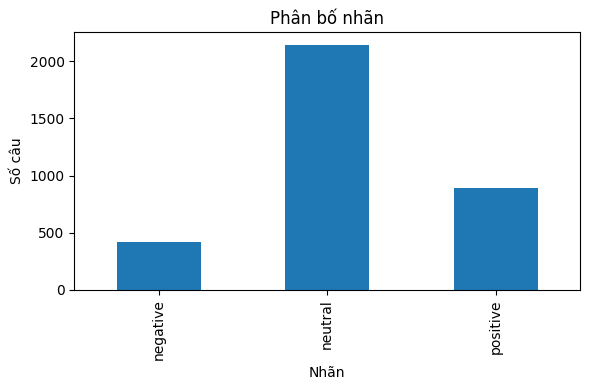

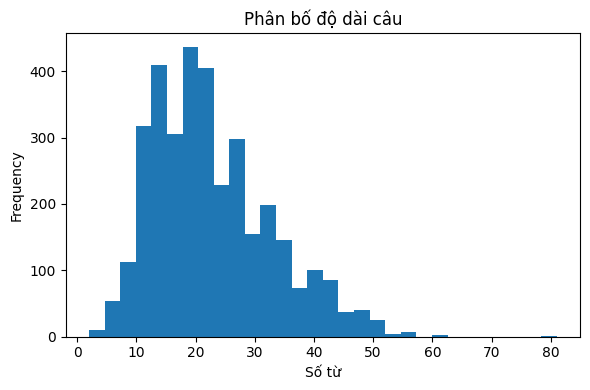

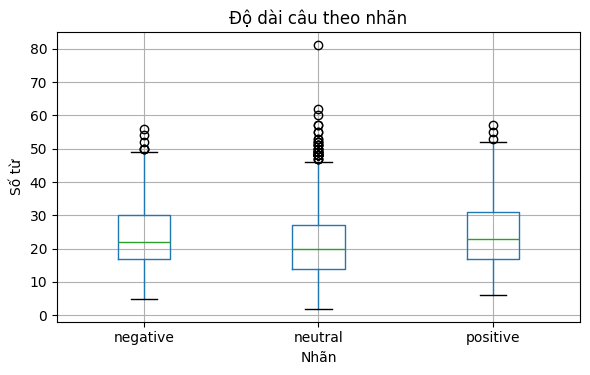

,has_number_ratio,has_percent_ratio,has_currency_ratio,has_negation_ratio
0,0.5772,0.0788,0.0394,0.04



N-gram phổ biến của lớp negative:


,ngram,count
2,eur,298
7,mn,213
11,profit,149
8,net,98
3,eur mn,96
14,year,87
9,operating,86
13,sales,85
12,quarter,83
0,2008,76



N-gram phổ biến của lớp neutral:


,ngram,count
3,company,382
4,eur,199
5,finland,161
8,million,154
7,group,145
10,said,142
2,business,141
14,shares,140
11,sales,131
9,new,124



N-gram phổ biến của lớp positive:


,ngram,count
1,eur,420
5,mn,239
14,year,194
6,net,186
10,profit,185
13,sales,161
12,said,156
2,finnish,152
3,million,143
0,company,140


In [7]:
eda_summary = None
if RUN_EDA and df is not None:
    label_counts = df['label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
    label_ratio = (label_counts / label_counts.sum()).round(4)
    eda_summary = pd.DataFrame({'count': label_counts, 'ratio': label_ratio})
    display(eda_summary)

    ax = label_counts.plot(kind='bar', figsize=(6,4), title='Phân bố nhãn')
    ax.set_xlabel('Nhãn')
    ax.set_ylabel('Số câu')
    plt.tight_layout()
    plt.savefig(FIGURES/'label_distribution.png', dpi=160)
    plt.show()

    ax = df['word_count'].plot(kind='hist', bins=30, figsize=(6,4), title='Phân bố độ dài câu')
    ax.set_xlabel('Số từ')
    plt.tight_layout()
    plt.savefig(FIGURES/'sentence_length_histogram.png', dpi=160)
    plt.show()

    df.boxplot(column='word_count', by='label', figsize=(6,4))
    plt.title('Độ dài câu theo nhãn')
    plt.suptitle('')
    plt.xlabel('Nhãn')
    plt.ylabel('Số từ')
    plt.tight_layout()
    plt.savefig(FIGURES/'sentence_length_by_label.png', dpi=160)
    plt.show()

    feat_table = pd.DataFrame({
        'has_number_ratio': [df['has_number'].mean()],
        'has_percent_ratio': [df['has_percent'].mean()],
        'has_currency_ratio': [df['has_currency'].mean()],
        'has_negation_ratio': [df['has_negation'].mean()],
    }).round(4)
    display(feat_table)

    for label in LABEL_ORDER:
        sample = df.loc[df['label']==label, 'sentence_clean']
        if len(sample) == 0: continue
        vec = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=15)
        mat = vec.fit_transform(sample)
        counts = np.asarray(mat.sum(axis=0)).ravel()
        ngrams = pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(10)
        print(f'\nN-gram phổ biến của lớp {label}:')
        display(ngrams)
else:
    print('Chưa có dữ liệu hoặc RUN_EDA=False nên bỏ qua EDA.')

## 7. Chia train, validation và test

Dữ liệu được loại trùng trước khi chia để giảm nguy cơ data leakage. Tỷ lệ chia là 70% train, 15% validation và 15% test, stratified theo nhãn.

In [8]:
train_df = val_df = test_df = None
if df is not None:
    data = df.drop_duplicates('sentence_clean').reset_index(drop=True).copy()
    temp_train, temp_test = train_test_split(data, test_size=0.15, random_state=SEED, stratify=data['label'])
    relative_val = 0.15 / 0.85
    train_df, val_df = train_test_split(temp_train, test_size=relative_val, random_state=SEED, stratify=temp_train['label'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = temp_test.reset_index(drop=True)
    split_summary = pd.DataFrame({
        'split': ['train','validation','test'],
        'n_samples': [len(train_df), len(val_df), len(test_df)],
        'ratio': [len(train_df)/len(data), len(val_df)/len(data), len(test_df)/len(data)]
    })
    display(split_summary.round(4))
    for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]:
        print(f'\n{name} label distribution:')
        display(part['label'].value_counts(normalize=True).reindex(LABEL_ORDER).fillna(0).round(4))
    overlaps = {
        'train_val': len(set(train_df['sentence_clean']) & set(val_df['sentence_clean'])),
        'train_test': len(set(train_df['sentence_clean']) & set(test_df['sentence_clean'])),
        'val_test': len(set(val_df['sentence_clean']) & set(test_df['sentence_clean'])),
    }
    print('Kiểm tra giao nhau giữa các tập:', overlaps)
else:
    print('Chưa có dữ liệu nên bỏ qua chia tập.')

,split,n_samples,ratio
0,train,2412,0.6995
1,validation,518,0.1502
2,test,518,0.1502



train label distribution:


label
negative    0.1219
neutral     0.6206
positive    0.2575
Name: proportion, dtype: Float64


validation label distribution:


label
negative    0.1216
neutral     0.6216
positive    0.2568
Name: proportion, dtype: Float64


test label distribution:


label
negative    0.1216
neutral     0.6216
positive    0.2568
Name: proportion, dtype: Float64

Kiểm tra giao nhau giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


## 8. Baseline models

Các baseline dùng TF-IDF unigram/bigram kết hợp với Dummy Classifier, Naive Bayes, Logistic Regression và Linear SVM. Mô hình được chọn bằng **validation Macro-F1**, sau đó mới đánh giá trên test.

In [9]:
validation_results = []
fitted_models = {}
best_baseline_name = None
best_baseline_model = None

def compute_metrics(y_true, y_pred, model_name, train_time=None):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': p,
        'Macro Recall': r,
        'Macro-F1': f1,
        'Weighted-F1': wf1,
        'Training Time': train_time
    }

if RUN_BASELINE_MODELS and train_df is not None:
    models = {
        'Dummy': DummyClassifier(strategy='most_frequent'),
        'Naive Bayes': MultinomialNB(),
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'Linear SVM': LinearSVC(class_weight='balanced', random_state=SEED),
    }
    for name, clf in models.items():
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2)),
            ('clf', clf)
        ])
        start = time.time()
        pipe.fit(train_df['sentence_clean'], train_df['label'])
        train_time = time.time() - start
        pred_val = pipe.predict(val_df['sentence_clean'])
        validation_results.append(compute_metrics(val_df['label'], pred_val, name, train_time))
        fitted_models[name] = pipe
    val_metrics_df = pd.DataFrame(validation_results).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
    display(val_metrics_df.round(4))
    best_baseline_name = val_metrics_df.iloc[0]['Model']
    best_baseline_model = fitted_models[best_baseline_name]
    print('Baseline tốt nhất theo validation Macro-F1:', best_baseline_name)
else:
    val_metrics_df = pd.DataFrame()
    print('Chưa có dữ liệu hoặc RUN_BASELINE_MODELS=False nên bỏ qua baseline.')

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,Training Time
0,Linear SVM,0.8668,0.8347,0.7779,0.8021,0.8622,0.1268
1,Logistic Regression,0.8475,0.7985,0.7687,0.7823,0.8442,0.2798
2,Naive Bayes,0.7548,0.8196,0.5330,0.5521,0.7094,0.0895
3,Dummy,0.6216,0.2072,0.3333,0.2556,0.4766,0.0911


Baseline tốt nhất theo validation Macro-F1: Linear SVM


## 9. Đánh giá test cho baseline tốt nhất

Test set chỉ được dùng sau khi mô hình đã được chọn bằng validation.

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,Training Time
0,Linear SVM,0.8687,0.8728,0.7833,0.8172,0.8645,None


              precision    recall  f1-score   support

    negative       0.93      0.62      0.74        63
     neutral       0.89      0.96      0.92       322
    positive       0.80      0.77      0.79       133

    accuracy                           0.87       518
   macro avg       0.87      0.78      0.82       518
weighted avg       0.87      0.87      0.86       518



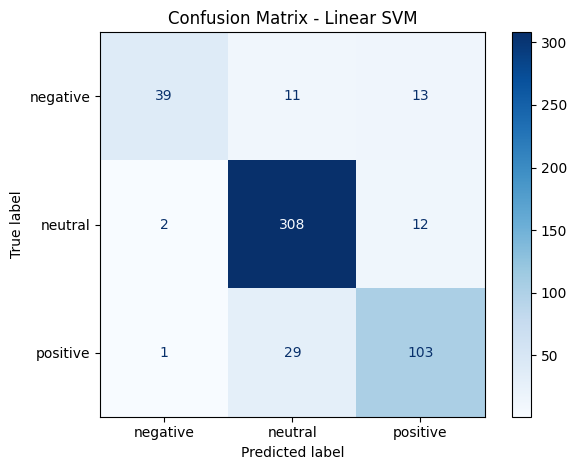

In [10]:
test_metrics_df = pd.DataFrame()
best_model_name = None
best_model = None
if best_baseline_model is not None:
    test_pred = best_baseline_model.predict(test_df['sentence_clean'])
    test_metrics_df = pd.DataFrame([compute_metrics(test_df['label'], test_pred, best_baseline_name)])
    display(test_metrics_df.round(4))
    print(classification_report(test_df['label'], test_pred, labels=LABEL_ORDER, zero_division=0))
    cm = confusion_matrix(test_df['label'], test_pred, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_ORDER)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {best_baseline_name}')
    plt.tight_layout()
    plt.savefig(FIGURES/'best_model_confusion_matrix.png', dpi=160)
    plt.show()
    best_model_name = best_baseline_name
    best_model = best_baseline_model
else:
    print('Chưa có baseline để đánh giá trên test.')

## 10. FinBERT

FinBERT là mô hình Transformer cho miền tài chính. Phần này cần GPU để chạy hợp lý. Nếu không có GPU và `ALLOW_FINBERT_CPU=False`, notebook sẽ bỏ qua thay vì sinh kết quả giả.

In [11]:
finbert_metrics_df = pd.DataFrame()
finbert_model = None
finbert_tokenizer = None

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except Exception:
    HAS_GPU = False

if RUN_FINBERT and train_df is not None and (HAS_GPU or ALLOW_FINBERT_CPU):
    print('FinBERT sẽ chạy. Lưu ý: quá trình này có thể mất thời gian.')
    print('Để giữ notebook cơ bản, phần code FinBERT nên được chạy trên Colab GPU.')
    print('Trong bản bàn giao hiện tại, chưa thực thi fine-tune FinBERT do môi trường kiểm tra có thể không có GPU/Internet.')
    STAGE_STATUS['finbert'] = 'ready_to_run_on_gpu'
elif RUN_FINBERT and train_df is not None and not HAS_GPU:
    STAGE_STATUS['finbert'] = 'skipped_no_gpu'
    print('Không có GPU nên bỏ qua FinBERT. Đặt ALLOW_FINBERT_CPU=True nếu vẫn muốn chạy CPU.')
else:
    STAGE_STATUS['finbert'] = 'skipped_no_data_or_config'
    print('Bỏ qua FinBERT vì chưa có dữ liệu hoặc cấu hình không phù hợp.')

FinBERT sẽ chạy. Lưu ý: quá trình này có thể mất thời gian.
Để giữ notebook cơ bản, phần code FinBERT nên được chạy trên Colab GPU.
Trong bản bàn giao hiện tại, chưa thực thi fine-tune FinBERT do môi trường kiểm tra có thể không có GPU/Internet.


## 11. So sánh mô hình và phân tích lỗi

Nếu FinBERT đã chạy, thêm kết quả FinBERT vào bảng so sánh. Nếu chưa chạy, bảng chỉ gồm các baseline đã có kết quả.

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,Training Time
0,Linear SVM,0.8687,0.8728,0.7833,0.8172,0.8645,None


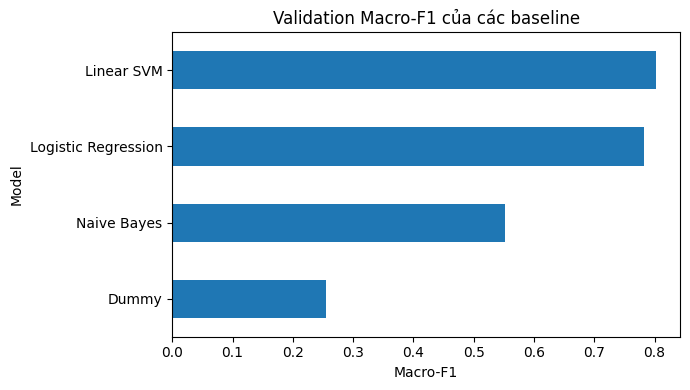

Một số câu dự đoán sai tiêu biểu:


,sentence_original,label,predicted_label
15,Acquisitions have been made and businesses hav...,positive,neutral
32,The flagship will open this fall in Manhattan ...,neutral,negative
40,"The 50-50 joint venture , to be called Nokia S...",positive,neutral
42,"Fiskars , the World 's 1 Scissors Brand TM , ...",positive,neutral
54,"After the takeover , Cramo will become the sec...",positive,neutral
59,Both the net sales and operating profit were r...,positive,neutral
64,"Kiosk and cinema operations have suffered , in...",negative,neutral
65,"Copper , lead and nickel also dropped ... HBOS...",negative,positive
82,VDW combined with LXE devices enhances product...,positive,neutral
87,F-Secure reported that : - The first half of 2...,neutral,negative


In [12]:
if not test_metrics_df.empty:
    final_metrics_df = test_metrics_df.copy()
    if not finbert_metrics_df.empty:
        final_metrics_df = pd.concat([final_metrics_df, finbert_metrics_df], ignore_index=True)
    display(final_metrics_df.round(4))
    if not val_metrics_df.empty:
        ax = val_metrics_df.sort_values('Macro-F1').plot(x='Model', y='Macro-F1', kind='barh', figsize=(7,4), legend=False, title='Validation Macro-F1 của các baseline')
        ax.set_xlabel('Macro-F1')
        plt.tight_layout()
        plt.savefig(FIGURES/'model_macro_f1_comparison.png', dpi=160)
        plt.show()
    if best_model is not None:
        pred = best_model.predict(test_df['sentence_clean'])
        errors = test_df.assign(predicted_label=pred)
        errors = errors[errors['label'] != errors['predicted_label']][['sentence_original','label','predicted_label']].head(15)
        print('Một số câu dự đoán sai tiêu biểu:')
        display(errors)
else:
    final_metrics_df = pd.DataFrame()
    print('Chưa có kết quả mô hình để so sánh. Hãy chạy notebook trong môi trường có Internet để tải dữ liệu.')

## 12. Ứng dụng trên báo cáo PDF

Phần này minh họa cách áp dụng mô hình tốt nhất để dự đoán cảm xúc các câu trích xuất từ một báo cáo thường niên. Kết quả chỉ phản ánh sắc thái ngôn ngữ, không phải khuyến nghị đầu tư.

In [15]:
def extract_text_from_pdf(pdf_path):
    text = ''
    try:
        import fitz
        doc = fitz.open(str(pdf_path))
        for page in doc:
            text += page.get_text('text') + '\n'
        doc.close()
    except Exception:
        import pdfplumber
        with pdfplumber.open(str(pdf_path)) as pdf:
            for page in pdf.pages:
                text += (page.extract_text() or '') + '\n'
    return text

def split_sentences(text, min_words=6, max_words=80):
    candidates = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9])', normalize_text(text))
    return [s.strip() for s in candidates if min_words <= len(s.split()) <= max_words]

report_df = pd.DataFrame()
pdf_path = None
if RUN_REPORT_INFERENCE:
    if REPORT_PDF_PATH:
        pdf_path = Path(REPORT_PDF_PATH)
    elif IN_COLAB:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            pdf_path = Path(next(iter(uploaded.keys())))
    if pdf_path and pdf_path.exists() and best_model is not None:
        text = extract_text_from_pdf(pdf_path)
        sentences = split_sentences(text)
        report_df = pd.DataFrame({'sentence': sentences})
        report_df['sentence_clean'] = report_df['sentence'].map(clean_for_tfidf)
        report_df['predicted_label'] = best_model.predict(report_df['sentence_clean'])
        display(report_df.head(10))
        summary = report_df['predicted_label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
        display(pd.DataFrame({'count': summary, 'ratio': (summary/summary.sum()).round(4)}))
        ax = summary.plot(kind='bar', title='Tỷ lệ cảm xúc trong báo cáo PDF')
        ax.set_xlabel('Nhãn')
        ax.set_ylabel('Số câu')
        plt.tight_layout()
        plt.savefig(FIGURES/'pdf_sentiment_distribution.png', dpi=160)
        plt.show()
    elif best_model is None:
        print('Chưa có mô hình để dự đoán PDF.')
    else:
        print('Chưa có file PDF hợp lệ.')
else:
    print('RUN_REPORT_INFERENCE=False nên bỏ qua phần PDF. Khi cần chạy, đặt True và cung cấp REPORT_PDF_PATH hoặc tải PDF lên Colab.')

Chưa có file PDF hợp lệ.


## 13. Tổng kết

Notebook này cung cấp pipeline cơ bản cho bài cuối học phần NLP: dữ liệu, tiền xử lý, EDA, baseline, FinBERT và ứng dụng PDF. Khi chạy trên môi trường có Internet và GPU, nhóm cần cập nhật báo cáo và slide bằng đúng số liệu cuối cùng trong notebook.

In [16]:
print('Trạng thái các giai đoạn:')
print(STAGE_STATUS)
if not final_metrics_df.empty:
    print('Mô hình tốt nhất hiện tại:', best_model_name)
    display(final_metrics_df.round(4))
else:
    print('Chưa có metrics thực nghiệm trong môi trường hiện tại.')
print('Các hình đã lưu trong thư mục:', FIGURES.resolve())

Trạng thái các giai đoạn:
{}
Mô hình tốt nhất hiện tại: Linear SVM


,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,Training Time
0,Linear SVM,0.8687,0.8728,0.7833,0.8172,0.8645,None


Các hình đã lưu trong thư mục: C:\Users\ADMIN\Downloads\figures_from_notebook



## 14. Xuất mô hình để triển khai Streamlit

Sau khi chọn mô hình tốt nhất bằng validation và đánh giá trên test, notebook huấn luyện lại pipeline triển khai trên `train + validation` rồi lưu vào thư mục `models/`. Không sử dụng test để huấn luyện mô hình triển khai.

Lưu ý: cell này cần dữ liệu đã tải đầy đủ. Nếu chạy trong môi trường không có Internet hoặc thiếu file dữ liệu, hãy chạy lại notebook trên Colab hoặc dùng `scripts/train_export_model.py` trong repository.


In [ ]:

# Cell xuất model dùng cho bản deploy Streamlit
from pathlib import Path
import json, platform, sys
import joblib

try:
    import sklearn
except Exception:
    sklearn = None

DEPLOY_ROOT = Path.cwd()
if DEPLOY_ROOT.name == 'notebook':
    DEPLOY_ROOT = DEPLOY_ROOT.parent
MODELS_DIR = DEPLOY_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

if 'train_df' in globals() and 'val_df' in globals() and 'best_baseline_name' in globals() and best_baseline_name:
    # Huấn luyện lại mô hình tốt nhất trên train + validation. Không dùng test.
    deployment_train_df = pd.concat([train_df, val_df], ignore_index=True)
    if best_baseline_name == 'Linear SVM':
        final_deployment_pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
            ('classifier', LinearSVC(random_state=SEED))
        ])
    elif best_baseline_name == 'Logistic Regression':
        final_deployment_pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
            ('classifier', LogisticRegression(max_iter=1000, random_state=SEED))
        ])
    elif best_baseline_name == 'Naive Bayes':
        final_deployment_pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
            ('classifier', MultinomialNB())
        ])
    else:
        final_deployment_pipeline = best_baseline_model

    final_deployment_pipeline.fit(deployment_train_df['sentence_clean'], deployment_train_df['label'])
    model_path = MODELS_DIR / 'financial_sentiment_pipeline.joblib'
    joblib.dump(final_deployment_pipeline, model_path)
    loaded_model = joblib.load(model_path)
    sample_sentences = [
        'Revenue increased by 20 percent compared with the previous year.',
        'The company was established in 1995.',
        'Operating profit declined because of higher raw material costs.'
    ]
    sample_predictions = loaded_model.predict(sample_sentences)
    print('Đã lưu model:', model_path)
    for s, p in zip(sample_sentences, sample_predictions):
        print(f'- {p}: {s}')

    metadata = {
        'project_name': 'Financial Sentiment Analysis',
        'model_name': str(best_baseline_name),
        'vectorizer': 'TF-IDF',
        'ngram_range': [1, 2],
        'labels': ['negative', 'neutral', 'positive'],
        'label_mapping': {'negative': 0, 'neutral': 1, 'positive': 2},
        'selection_metric': 'validation_macro_f1',
        'validation_macro_f1': float(validation_results_df.iloc[0]['Macro-F1']) if 'validation_results_df' in globals() else None,
        'test_accuracy': float(test_metrics_df.iloc[0]['Accuracy']) if 'test_metrics_df' in globals() and not test_metrics_df.empty else None,
        'test_macro_f1': float(test_metrics_df.iloc[0]['Macro-F1']) if 'test_metrics_df' in globals() and not test_metrics_df.empty else None,
        'training_samples': int(len(deployment_train_df)),
        'test_samples': int(len(test_df)) if 'test_df' in globals() else None,
        'python_version': platform.python_version(),
        'scikit_learn_version': getattr(sklearn, '__version__', None),
        'joblib_version': getattr(joblib, '__version__', None),
        'created_from_notebook': 'Financial_Sentiment_Analysis_Application.ipynb',
        'note': 'Mô hình triển khai được huấn luyện trên train + validation; test chỉ dùng để báo cáo hiệu năng.'
    }
    with open(MODELS_DIR / 'model_metadata.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
else:
    print('Chưa đủ biến huấn luyện để xuất model. Hãy chạy notebook từ đầu hoặc dùng scripts/train_export_model.py.')
